# 第16章: 重回帰分析

## 学習目標
- 重回帰モデルを理解する
- 最小二乗法による推定を実行できる
- 回帰係数の仮説検定を行える
- 決定係数を解釈できる
- 多重共線性を検出し対処できる

## 📋 学習メタ情報

### 推定学習時間
**100〜130分**

### 難易度
**★★★☆☆** (5段階中3)

---

## 🎯 なぜこの章を学ぶのか？

この章の内容は、実務での統計的データ分析に直結する重要なトピックです。理論と実践の両面から理解を深めましょう。

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')
np.random.seed(42)

## 16.1 重回帰モデル

### モデル
$$Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \cdots + \beta_p X_p + \varepsilon$$

### 行列表現
$$\mathbf{y} = \mathbf{X}\boldsymbol{\beta} + \boldsymbol{\varepsilon}$$

ここで:
- $\mathbf{y}$: $n \times 1$ 応答変数ベクトル
- $\mathbf{X}$: $n \times (p+1)$ 計画行列（最初の列は1）
- $\boldsymbol{\beta}$: $(p+1) \times 1$ パラメータベクトル
- $\boldsymbol{\varepsilon}$: $n \times 1$ 誤差ベクトル、$\varepsilon_i \sim N(0, \sigma^2)$

### 仮定
1. 線形性
2. 誤差の独立性
3. 等分散性
4. 正規性

重回帰モデルの例

真のモデル: Y = 2.0 + 3.0*X1 + (-1.5)*X2 + ε
誤差の標準偏差: σ = 2
サンプルサイズ: n = 100


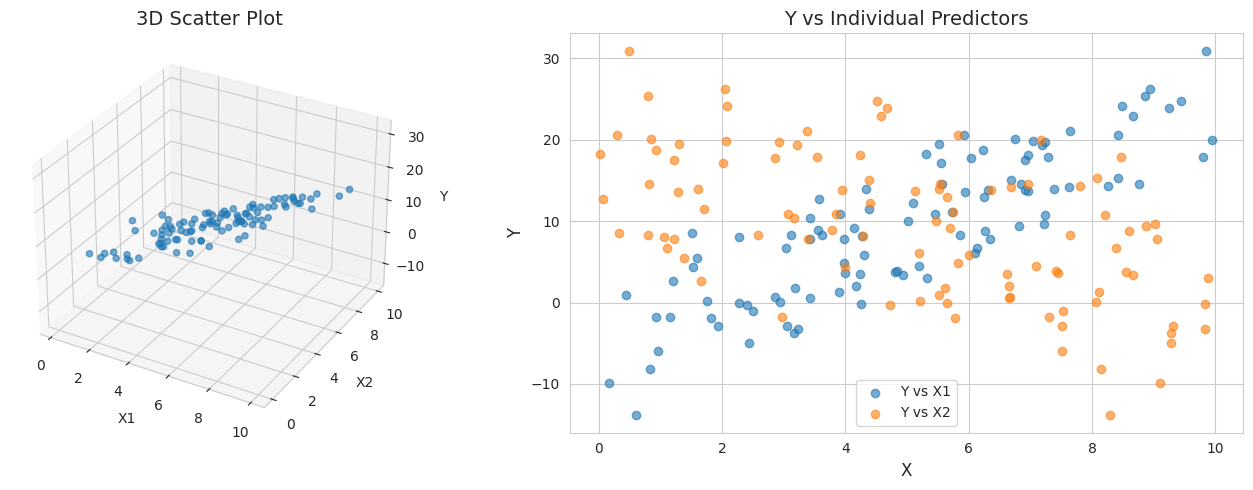

In [2]:
# 重回帰データの生成
np.random.seed(123)

n = 100
X1 = np.random.uniform(0, 10, n)
X2 = np.random.uniform(0, 10, n)

# True model: Y = 2 + 3*X1 - 1.5*X2 + error
beta_true = np.array([2, 3, -1.5])
sigma = 2
Y = beta_true[0] + beta_true[1]*X1 + beta_true[2]*X2 + np.random.normal(0, sigma, n)

print("重回帰モデルの例")
print("="*50)
print(f"\n真のモデル: Y = {beta_true[0]} + {beta_true[1]}*X1 + ({beta_true[2]})*X2 + ε")
print(f"誤差の標準偏差: σ = {sigma}")
print(f"サンプルサイズ: n = {n}")

# Visualization
fig = plt.figure(figsize=(14, 5))

# 3D scatter plot
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(X1, X2, Y, alpha=0.6)
ax1.set_xlabel('X1', fontsize=10)
ax1.set_ylabel('X2', fontsize=10)
ax1.set_zlabel('Y', fontsize=10)
ax1.set_title('3D Scatter Plot', fontsize=14)

# 2D projections
ax2 = fig.add_subplot(122)
ax2.scatter(X1, Y, alpha=0.6, label='Y vs X1')
ax2.scatter(X2, Y, alpha=0.6, label='Y vs X2')
ax2.set_xlabel('X', fontsize=12)
ax2.set_ylabel('Y', fontsize=12)
ax2.set_title('Y vs Individual Predictors', fontsize=14)
ax2.legend()

plt.tight_layout()
plt.show()

## 16.2 最小二乗法 (OLS)

### 目的関数
$$S(\boldsymbol{\beta}) = \sum_{i=1}^{n} (y_i - \mathbf{x}_i^T \boldsymbol{\beta})^2 = (\mathbf{y} - \mathbf{X}\boldsymbol{\beta})^T(\mathbf{y} - \mathbf{X}\boldsymbol{\beta})$$

### 正規方程式
$$\mathbf{X}^T\mathbf{X}\hat{\boldsymbol{\beta}} = \mathbf{X}^T\mathbf{y}$$

### OLS推定量
$$\hat{\boldsymbol{\beta}} = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}$$

### 予測値と残差
- 予測値: $\hat{\mathbf{y}} = \mathbf{X}\hat{\boldsymbol{\beta}} = \mathbf{H}\mathbf{y}$
- ハット行列: $\mathbf{H} = \mathbf{X}(\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T$
- 残差: $\hat{\boldsymbol{\varepsilon}} = \mathbf{y} - \hat{\mathbf{y}}$

In [3]:
# OLS推定の実装
def ols_regression(X, y):
    """Perform OLS regression and return results."""
    n = len(y)
    
    # Add intercept column
    X_design = np.column_stack([np.ones(n), X])
    p = X_design.shape[1] - 1  # Number of predictors
    
    # OLS estimates
    XtX = X_design.T @ X_design
    XtX_inv = np.linalg.inv(XtX)
    beta_hat = XtX_inv @ X_design.T @ y
    
    # Fitted values and residuals
    y_hat = X_design @ beta_hat
    residuals = y - y_hat
    
    # Residual sum of squares and MSE
    RSS = np.sum(residuals**2)
    MSE = RSS / (n - p - 1)
    sigma_hat = np.sqrt(MSE)
    
    # Standard errors
    se_beta = np.sqrt(np.diag(MSE * XtX_inv))
    
    # t-statistics and p-values
    t_stats = beta_hat / se_beta
    p_values = 2 * (1 - stats.t.cdf(np.abs(t_stats), n - p - 1))
    
    return {
        'beta': beta_hat,
        'se': se_beta,
        't_stat': t_stats,
        'p_value': p_values,
        'y_hat': y_hat,
        'residuals': residuals,
        'sigma': sigma_hat,
        'RSS': RSS,
        'XtX_inv': XtX_inv
    }

# Fit model
X = np.column_stack([X1, X2])
results = ols_regression(X, Y)

print("OLS推定結果")
print("="*60)
print(f"\n{'変数':<10} {'推定値':>10} {'標準誤差':>10} {'t値':>10} {'p値':>10}")
print("-"*60)
var_names = ['Intercept', 'X1', 'X2']
for i in range(3):
    print(f"{var_names[i]:<10} {results['beta'][i]:>10.4f} {results['se'][i]:>10.4f} "
          f"{results['t_stat'][i]:>10.4f} {results['p_value'][i]:>10.4f}")

print(f"\n残差標準誤差: {results['sigma']:.4f}")
print(f"\n真の係数: {beta_true}")

OLS推定結果

変数                推定値       標準誤差         t値         p値
------------------------------------------------------------
Intercept      2.3403     0.5693     4.1108     0.0001
X1             2.9081     0.0774    37.5809     0.0000
X2            -1.5021     0.0667   -22.5145     0.0000

残差標準誤差: 1.8906

真の係数: [ 2.   3.  -1.5]


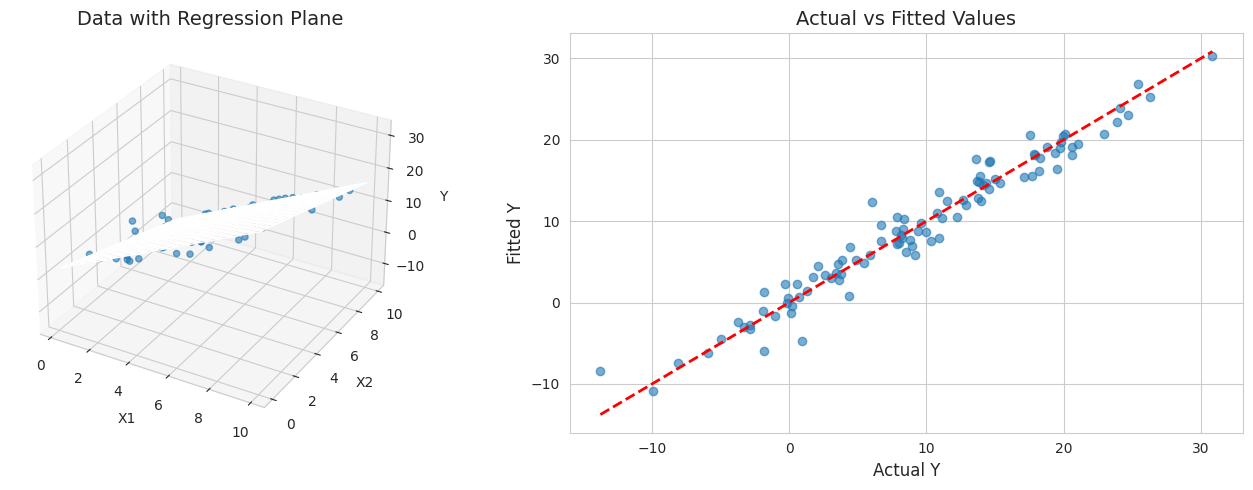

In [4]:
# 回帰平面の可視化
fig = plt.figure(figsize=(14, 5))

# 3D plot with regression plane
ax1 = fig.add_subplot(121, projection='3d')

# Create mesh for regression plane
x1_range = np.linspace(X1.min(), X1.max(), 20)
x2_range = np.linspace(X2.min(), X2.max(), 20)
X1_mesh, X2_mesh = np.meshgrid(x1_range, x2_range)
Y_mesh = results['beta'][0] + results['beta'][1]*X1_mesh + results['beta'][2]*X2_mesh

# Plot surface
ax1.plot_surface(X1_mesh, X2_mesh, Y_mesh, alpha=0.3, color='red')
ax1.scatter(X1, X2, Y, alpha=0.6)
ax1.set_xlabel('X1')
ax1.set_ylabel('X2')
ax1.set_zlabel('Y')
ax1.set_title('Data with Regression Plane', fontsize=14)

# Actual vs Fitted
ax2 = fig.add_subplot(122)
ax2.scatter(Y, results['y_hat'], alpha=0.6)
ax2.plot([Y.min(), Y.max()], [Y.min(), Y.max()], 'r--', linewidth=2)
ax2.set_xlabel('Actual Y', fontsize=12)
ax2.set_ylabel('Fitted Y', fontsize=12)
ax2.set_title('Actual vs Fitted Values', fontsize=14)

plt.tight_layout()
plt.show()

## 16.3 回帰係数の仮説検定

### 個別係数の検定
$$H_0: \beta_j = 0 \quad \text{vs} \quad H_1: \beta_j \neq 0$$

検定統計量:
$$t = \frac{\hat{\beta}_j}{\text{SE}(\hat{\beta}_j)} \sim t_{n-p-1}$$

### モデル全体の検定（F検定）
$$H_0: \beta_1 = \beta_2 = \cdots = \beta_p = 0$$

検定統計量:
$$F = \frac{(TSS - RSS)/p}{RSS/(n-p-1)} = \frac{MSR}{MSE} \sim F_{p, n-p-1}$$

ここで:
- TSS = $\sum(y_i - \bar{y})^2$ (全変動)
- RSS = $\sum(y_i - \hat{y}_i)^2$ (残差変動)
- ESS = TSS - RSS (回帰変動)

In [5]:
# F検定と分散分析表
def anova_table(X, y, results):
    """Create ANOVA table for regression."""
    n = len(y)
    p = X.shape[1] if len(X.shape) > 1 else 1
    
    # Sum of squares
    TSS = np.sum((y - np.mean(y))**2)
    RSS = results['RSS']
    ESS = TSS - RSS
    
    # Degrees of freedom
    df_reg = p
    df_res = n - p - 1
    df_total = n - 1
    
    # Mean squares
    MSR = ESS / df_reg
    MSE = RSS / df_res
    
    # F statistic
    F_stat = MSR / MSE
    p_value = 1 - stats.f.cdf(F_stat, df_reg, df_res)
    
    return {
        'TSS': TSS, 'ESS': ESS, 'RSS': RSS,
        'df_reg': df_reg, 'df_res': df_res, 'df_total': df_total,
        'MSR': MSR, 'MSE': MSE,
        'F_stat': F_stat, 'p_value': p_value
    }

anova = anova_table(X, Y, results)

print("分散分析表 (ANOVA)")
print("="*70)
print(f"\n{'Source':<12} {'SS':>12} {'df':>6} {'MS':>12} {'F':>10} {'p-value':>10}")
print("-"*70)
print(f"{'Regression':<12} {anova['ESS']:>12.2f} {anova['df_reg']:>6} {anova['MSR']:>12.2f} "
      f"{anova['F_stat']:>10.2f} {anova['p_value']:>10.6f}")
print(f"{'Residual':<12} {anova['RSS']:>12.2f} {anova['df_res']:>6} {anova['MSE']:>12.2f}")
print(f"{'Total':<12} {anova['TSS']:>12.2f} {anova['df_total']:>6}")

print(f"\n結論: F = {anova['F_stat']:.2f}, p = {anova['p_value']:.6f}")
if anova['p_value'] < 0.05:
    print("→ モデルは統計的に有意（少なくとも1つの係数が0でない）")

分散分析表 (ANOVA)

Source                 SS     df           MS          F    p-value
----------------------------------------------------------------------
Regression        7485.20      2      3742.60    1047.05   0.000000
Residual           346.72     97         3.57
Total             7831.92     99

結論: F = 1047.05, p = 0.000000
→ モデルは統計的に有意（少なくとも1つの係数が0でない）


## 16.4 決定係数

### R二乗
$$R^2 = 1 - \frac{RSS}{TSS} = \frac{ESS}{TSS}$$

- $0 \leq R^2 \leq 1$
- モデルにより説明される変動の割合

### 自由度調整済みR二乗
$$\bar{R}^2 = 1 - \frac{RSS/(n-p-1)}{TSS/(n-1)} = 1 - \frac{n-1}{n-p-1}(1-R^2)$$

変数の数を増やしても自動的には増加しない

In [6]:
# 決定係数の計算
def calculate_r_squared(y, y_hat, p):
    """Calculate R-squared and adjusted R-squared."""
    n = len(y)
    TSS = np.sum((y - np.mean(y))**2)
    RSS = np.sum((y - y_hat)**2)
    
    R2 = 1 - RSS/TSS
    R2_adj = 1 - (n-1)/(n-p-1) * (1 - R2)
    
    return R2, R2_adj

R2, R2_adj = calculate_r_squared(Y, results['y_hat'], 2)

print("決定係数")
print("="*50)
print(f"\nR² = {R2:.4f}")
print(f"調整済みR² = {R2_adj:.4f}")
print(f"\n解釈: モデルはYの変動の{R2*100:.1f}%を説明している")

# Demonstrate effect of adding irrelevant variables
print("\n不要な変数を追加した場合:")
print("-"*50)

for n_extra in range(5):
    # Add random noise variables
    X_extra = np.column_stack([X] + [np.random.normal(0, 1, n) for _ in range(n_extra)])
    results_extra = ols_regression(X_extra, Y)
    R2_new, R2_adj_new = calculate_r_squared(Y, results_extra['y_hat'], 2 + n_extra)
    
    print(f"変数数 = {2 + n_extra}: R² = {R2_new:.4f}, 調整済みR² = {R2_adj_new:.4f}")

決定係数

R² = 0.9557
調整済みR² = 0.9548

解釈: モデルはYの変動の95.6%を説明している

不要な変数を追加した場合:
--------------------------------------------------
変数数 = 2: R² = 0.9557, 調整済みR² = 0.9548
変数数 = 3: R² = 0.9558, 調整済みR² = 0.9544
変数数 = 4: R² = 0.9558, 調整済みR² = 0.9540
変数数 = 5: R² = 0.9605, 調整済みR² = 0.9584
変数数 = 6: R² = 0.9571, 調整済みR² = 0.9544


## 16.5 多重共線性

### 定義
説明変数間に強い線形関係があるとき、多重共線性が生じる。

### 問題点
- 係数の推定値が不安定
- 標準誤差が大きくなる
- 係数の符号が理論と逆になることも

### 検出方法
1. **相関行列**: 変数間の高い相関
2. **VIF (Variance Inflation Factor)**:
   $$VIF_j = \frac{1}{1 - R_j^2}$$
   ここで $R_j^2$ は $X_j$ を他の変数で回帰したときの決定係数
   - VIF > 10 は多重共線性の兆候

3. **条件数**: $\mathbf{X}^T\mathbf{X}$ の最大固有値と最小固有値の比

In [7]:
# 多重共線性の例
np.random.seed(456)

n = 100
X1 = np.random.uniform(0, 10, n)
X2 = 2 * X1 + np.random.normal(0, 0.1, n)  # Highly correlated with X1
X3 = np.random.uniform(0, 10, n)  # Independent

Y_collinear = 2 + 3*X1 - 1.5*X2 + 2*X3 + np.random.normal(0, 1, n)

# Correlation matrix
X_all = np.column_stack([X1, X2, X3])
corr_matrix = np.corrcoef(X_all.T)

print("多重共線性の例")
print("="*50)
print("\n相関行列:")
print(f"       X1      X2      X3")
for i, name in enumerate(['X1', 'X2', 'X3']):
    print(f"{name}  {corr_matrix[i, 0]:.4f}  {corr_matrix[i, 1]:.4f}  {corr_matrix[i, 2]:.4f}")

# VIF calculation
def calculate_vif(X):
    """Calculate VIF for each variable."""
    n_vars = X.shape[1]
    vif = np.zeros(n_vars)
    
    for j in range(n_vars):
        X_others = np.delete(X, j, axis=1)
        results = ols_regression(X_others, X[:, j])
        R2 = 1 - results['RSS'] / np.sum((X[:, j] - np.mean(X[:, j]))**2)
        vif[j] = 1 / (1 - R2)
    
    return vif

vif = calculate_vif(X_all)
print(f"\nVIF:")
for i, name in enumerate(['X1', 'X2', 'X3']):
    flag = ' (高い多重共線性!)' if vif[i] > 10 else ''
    print(f"  {name}: {vif[i]:.2f}{flag}")

多重共線性の例

相関行列:
       X1      X2      X3
X1  1.0000  0.9998  0.2530
X2  0.9998  1.0000  0.2544
X3  0.2530  0.2544  1.0000

VIF:
  X1: 2888.47 (高い多重共線性!)
  X2: 2890.55 (高い多重共線性!)
  X3: 1.07


多重共線性が回帰に与える影響

変数                推定値       標準誤差         t値         p値
------------------------------------------------------------
Intercept      1.8518     0.2776     6.6701     0.0000
X1             2.5162     1.9414     1.2961     0.1981
X2            -1.2498     0.9735    -1.2838     0.2023
X3             2.0053     0.0422    47.5381     0.0000

注: X1とX2の推定値が不安定で標準誤差が大きい

X2を除いたモデル:

変数                推定値       標準誤差
----------------------------------------
Intercept      1.8362     0.2783
X1             0.0242     0.0375
X3             2.0012     0.0422


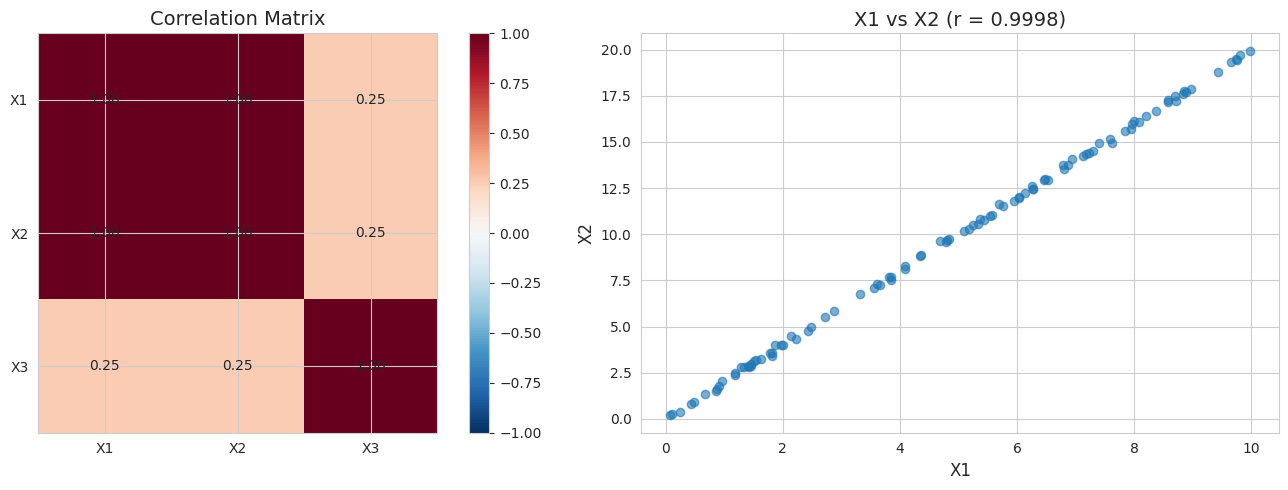

In [8]:
# 多重共線性の影響
print("多重共線性が回帰に与える影響")
print("="*60)

# Fit model with collinearity
results_collinear = ols_regression(X_all, Y_collinear)

print(f"\n{'変数':<10} {'推定値':>10} {'標準誤差':>10} {'t値':>10} {'p値':>10}")
print("-"*60)
var_names = ['Intercept', 'X1', 'X2', 'X3']
for i in range(4):
    print(f"{var_names[i]:<10} {results_collinear['beta'][i]:>10.4f} "
          f"{results_collinear['se'][i]:>10.4f} "
          f"{results_collinear['t_stat'][i]:>10.4f} {results_collinear['p_value'][i]:>10.4f}")

print(f"\n注: X1とX2の推定値が不安定で標準誤差が大きい")

# Compare with model without X2
print("\nX2を除いたモデル:")
X_reduced = np.column_stack([X1, X3])
results_reduced = ols_regression(X_reduced, Y_collinear)

print(f"\n{'変数':<10} {'推定値':>10} {'標準誤差':>10}")
print("-"*40)
var_names = ['Intercept', 'X1', 'X3']
for i in range(3):
    print(f"{var_names[i]:<10} {results_reduced['beta'][i]:>10.4f} "
          f"{results_reduced['se'][i]:>10.4f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Correlation heatmap
im = axes[0].imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1)
axes[0].set_xticks(range(3))
axes[0].set_yticks(range(3))
axes[0].set_xticklabels(['X1', 'X2', 'X3'])
axes[0].set_yticklabels(['X1', 'X2', 'X3'])
axes[0].set_title('Correlation Matrix', fontsize=14)
for i in range(3):
    for j in range(3):
        axes[0].text(j, i, f'{corr_matrix[i,j]:.2f}', ha='center', va='center')
plt.colorbar(im, ax=axes[0])

# X1 vs X2 scatter
axes[1].scatter(X1, X2, alpha=0.6)
axes[1].set_xlabel('X1', fontsize=12)
axes[1].set_ylabel('X2', fontsize=12)
axes[1].set_title(f'X1 vs X2 (r = {corr_matrix[0,1]:.4f})', fontsize=14)

plt.tight_layout()
plt.show()

## 16.6 練習問題

### 問題1
以下のデータについて重回帰分析を行い、回帰係数を求めよ。

Y = [10, 15, 13, 18, 20, 17, 22, 25, 23, 28]
X1 = [1, 2, 2, 3, 4, 3, 5, 6, 5, 7]
X2 = [5, 4, 6, 5, 4, 6, 3, 2, 4, 1]

### 問題2
問題1のモデルについて:
(a) F検定を行い、モデル全体の有意性を検定せよ
(b) 各係数のt検定を行え
(c) R²を計算せよ

### 問題3
以下の変数間の相関から、多重共線性の問題があるか判断し、VIFを概算せよ。
- $r_{12} = 0.95$
- $r_{13} = 0.10$
- $r_{23} = 0.15$

In [9]:
# 問題1の解答
print("問題1: 重回帰分析")
print("="*50)

Y = np.array([10, 15, 13, 18, 20, 17, 22, 25, 23, 28])
X1 = np.array([1, 2, 2, 3, 4, 3, 5, 6, 5, 7])
X2 = np.array([5, 4, 6, 5, 4, 6, 3, 2, 4, 1])

X = np.column_stack([X1, X2])
results = ols_regression(X, Y)

print(f"\n回帰式: Y = {results['beta'][0]:.4f} + {results['beta'][1]:.4f}*X1 + "
      f"({results['beta'][2]:.4f})*X2")

問題1: 重回帰分析

回帰式: Y = 7.5208 + 2.9375*X1 + (0.1042)*X2


In [10]:
# 問題2の解答
print("問題2: 統計的検定")
print("="*60)

# (a) F検定
anova = anova_table(X, Y, results)
print(f"\n(a) F検定")
print(f"    F = {anova['F_stat']:.4f}")
print(f"    p値 = {anova['p_value']:.6f}")
print(f"    → モデルは{'有意' if anova['p_value'] < 0.05 else '有意でない'}")

# (b) t検定
print(f"\n(b) 各係数のt検定")
print(f"    {'変数':<10} {'t値':>10} {'p値':>10}")
print(f"    {'-'*35}")
for i, name in enumerate(['Intercept', 'X1', 'X2']):
    print(f"    {name:<10} {results['t_stat'][i]:>10.4f} {results['p_value'][i]:>10.4f}")

# (c) R²
R2, R2_adj = calculate_r_squared(Y, results['y_hat'], 2)
print(f"\n(c) R² = {R2:.4f}")
print(f"    調整済みR² = {R2_adj:.4f}")

問題2: 統計的検定

(a) F検定
    F = 178.7054
    p値 = 0.000001
    → モデルは有意

(b) 各係数のt検定
    変数                 t値         p値
    -----------------------------------
    Intercept      3.2139     0.0148
    X1            10.3665     0.0000
    X2             0.3107     0.7651

(c) R² = 0.9808
    調整済みR² = 0.9753


In [11]:
# 問題3の解答
print("問題3: 多重共線性の判断")
print("="*50)

r12 = 0.95
r13 = 0.10
r23 = 0.15

print(f"\n相関係数:")
print(f"  r(X1, X2) = {r12}")
print(f"  r(X1, X3) = {r13}")
print(f"  r(X2, X3) = {r23}")

print(f"\n判断: X1とX2の間に強い相関があり、多重共線性の問題がある可能性が高い")

# Approximate VIF for X1 (regressed on X2 and X3)
# R1² ≈ r12² (since r13 and r23 are small)
R1_sq_approx = r12**2
VIF_X1_approx = 1 / (1 - R1_sq_approx)

# Similar for X2
R2_sq_approx = r12**2
VIF_X2_approx = 1 / (1 - R2_sq_approx)

# For X3 (small correlations with X1 and X2)
R3_sq_approx = r13**2 + r23**2
VIF_X3_approx = 1 / (1 - R3_sq_approx)

print(f"\nVIFの概算:")
print(f"  VIF(X1) ≈ {VIF_X1_approx:.2f} (> 10: 多重共線性あり)")
print(f"  VIF(X2) ≈ {VIF_X2_approx:.2f} (> 10: 多重共線性あり)")
print(f"  VIF(X3) ≈ {VIF_X3_approx:.2f} (問題なし)")

問題3: 多重共線性の判断

相関係数:
  r(X1, X2) = 0.95
  r(X1, X3) = 0.1
  r(X2, X3) = 0.15

判断: X1とX2の間に強い相関があり、多重共線性の問題がある可能性が高い

VIFの概算:
  VIF(X1) ≈ 10.26 (> 10: 多重共線性あり)
  VIF(X2) ≈ 10.26 (> 10: 多重共線性あり)
  VIF(X3) ≈ 1.03 (問題なし)


## ⚠️ よくある間違いと解決策

統計分析では、手法の前提条件を確認せずに適用してしまうことがよくあります。必ず前提を確認し、適切な手法を選択しましょう。

---

## 📝 理解度チェック

この章で学んだ内容を振り返り、重要な概念を自分の言葉で説明できるか確認しましょう。

---

## 📚 まとめ

お疲れ様でした！この章で学んだ手法は、実際のデータ分析で頻繁に使われます。実データで試して理解を深めましょう。

---